In [1]:
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn as sns

print("Library Versions")
print("-" * 40)
print(f"Pandas         : {pd.__version__}")
print(f"NumPy          : {np.__version__}")
print(f"Scikit-learn   : {sklearn.__version__}")
print(f"Matplotlib     : {matplotlib.__version__}")
print(f"Seaborn        : {sns.__version__}")

Library Versions
----------------------------------------
Pandas         : 2.2.3
NumPy          : 2.1.3
Scikit-learn   : 1.6.1
Matplotlib     : 3.10.0
Seaborn        : 0.13.2


In [2]:
from pandas import read_csv
df=read_csv("/content/Smart_Parking_Dataset_project.csv")

In [3]:
df.tail(5)

,Record_ID,Parking_Lot_ID,Parking_Lot_Name,Date,Time,Day_of_Week,Is_Weekend,Weather,Temperature_C,Holiday,Capacity,Occupied_Spaces,Available_Spaces,Occupancy_Rate,Parking_Status
106303,106304,P004,Airport,2025-02-19,08:00,Wednesday,No,Rainy,37.0,No,350.0,276.0,74.0,0.79,Available
106304,106305,P008,Bus Station,2025-02-19,09:00,Wednesday,No,Cloudy,19.0,No,300.0,236.0,64.0,0.79,Available
106305,106306,P007,University,2025-02-19,10:00,Wednesday,No,Rainy,27.0,No,200.0,155.0,45.0,0.78,Available
106306,106307,P003,Railway Station,2025-02-19,11:00,Wednesday,No,Rainy,25.0,No,250.0,116.0,134.0,0.46,Available
106307,106308,P005,Tech Park,2025-02-19,12:00,Wednesday,No,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df['Time']
df.shape

(106308, 15)

In [5]:
df.dtypes

,0
Record_ID,int64
Parking_Lot_ID,object
Parking_Lot_Name,object
Date,object
Time,object
Day_of_Week,object
Is_Weekend,object
Weather,object
Temperature_C,float64
Holiday,object


In [6]:
df.Time

,Time
0,01:00
1,02:00
2,03:00
3,04:00
4,05:00
...,...
106303,08:00
106304,09:00
106305,10:00
106306,11:00


In [7]:
missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})
missing_data

,Missing Values,Percentage
Record_ID,0,0.000000
Parking_Lot_ID,0,0.000000
Parking_Lot_Name,0,0.000000
Date,0,0.000000
Time,0,0.000000
Day_of_Week,0,0.000000
Is_Weekend,0,0.000000
Weather,0,0.000000
Temperature_C,1,0.000941
Holiday,1,0.000941


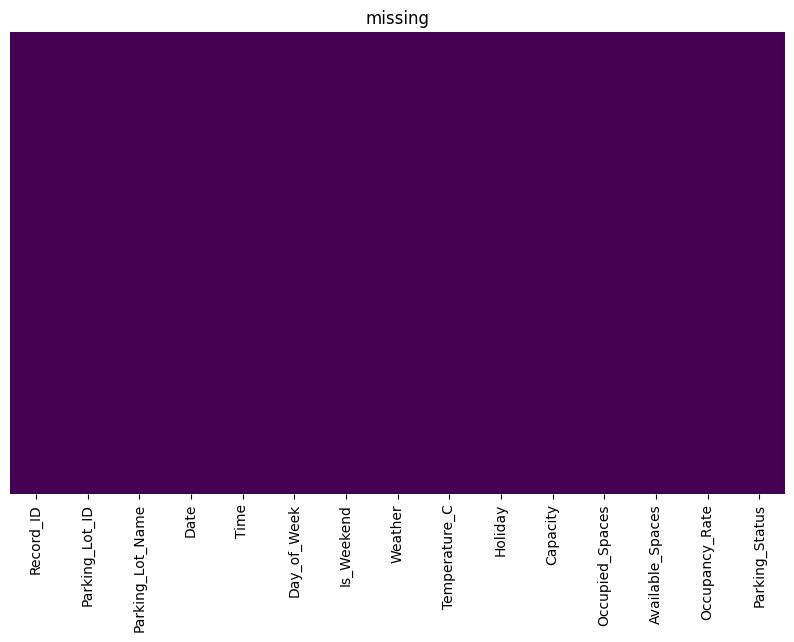

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
# cbar=False hides the color bar; yticklabels=False hides row numbers for cleaner v
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("missing")
plt.show()

In [9]:
duplicate_rows = df[df.duplicated()]
print(f"Total duplicate rows detected: {len(duplicate_rows)}")
print(duplicate_rows)
print("-" * 40)

Total duplicate rows detected: 0
Empty DataFrame
Columns: [Record_ID, Parking_Lot_ID, Parking_Lot_Name, Date, Time, Day_of_Week, Is_Weekend, Weather, Temperature_C, Holiday, Capacity, Occupied_Spaces, Available_Spaces, Occupancy_Rate, Parking_Status]
Index: []
----------------------------------------


In [11]:
df[df['Temperature_C'].isnull()]

,Record_ID,Parking_Lot_ID,Parking_Lot_Name,Date,Time,Day_of_Week,Is_Weekend,Weather,Temperature_C,Holiday,Capacity,Occupied_Spaces,Available_Spaces,Occupancy_Rate,Parking_Status
106307,106308,P005,Tech Park,2025-02-19,12:00,Wednesday,No,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.duplicated().sum()
df = df.drop_duplicates()
duplicate_rows

,Record_ID,Parking_Lot_ID,Parking_Lot_Name,Date,Time,Day_of_Week,Is_Weekend,Weather,Temperature_C,Holiday,Capacity,Occupied_Spaces,Available_Spaces,Occupancy_Rate,Parking_Status


In [14]:
df.describe()

,Record_ID,Temperature_C,Capacity,Occupied_Spaces,Available_Spaces,Occupancy_Rate
count,106308.000000,106307.000000,106307.000000,106307.000000,106307.000000,106307.000000
mean,53154.500000,28.988599,227.144214,118.852926,108.291288,0.523146
std,30688.620546,6.634723,98.531478,67.073936,63.435138,0.179980
min,1.000000,18.000000,100.000000,15.000000,0.000000,0.150000
25%,26577.750000,23.000000,150.000000,69.000000,59.000000,0.390000
50%,53154.500000,29.000000,200.000000,104.000000,93.000000,0.470000
75%,79731.250000,35.000000,300.000000,153.000000,152.000000,0.680000
max,106308.000000,40.000000,400.000000,340.000000,280.000000,1.000000


In [15]:
df = df.drop_duplicates()

In [16]:
df.shape

(106308, 15)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
import pandas as pd
import numpy as np

In [19]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['Record_ID', 'Temperature_C', 'Capacity', 'Occupied_Spaces', 'Available_Spaces', 'Occupancy_Rate']
Categorical Features: ['Parking_Lot_ID', 'Parking_Lot_Name', 'Date', 'Time', 'Day_of_Week', 'Is_Weekend', 'Weather', 'Holiday', 'Parking_Status']


<Figure size 1500x800 with 0 Axes>

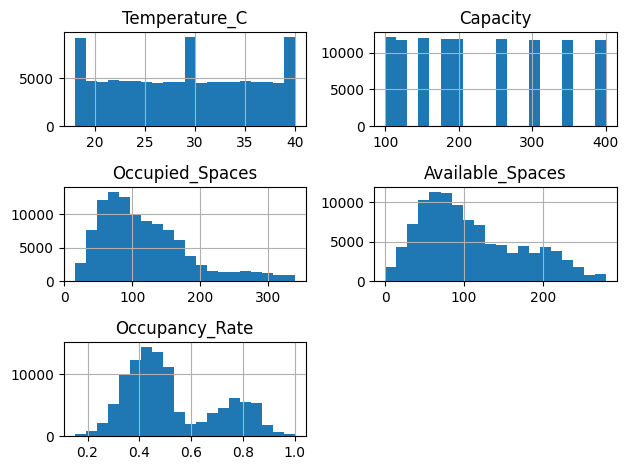

In [20]:
features = ["Parking_Lot_ID", "Time", "Temperature_C", "Holiday","Capacity", "Occupied_Spaces","Available_Spaces","Occupancy_Rate" ]

fig2=plt.figure(figsize=(15,8))
df[features].hist(
    bins=20
)

plt.tight_layout()

plt.show()

In [21]:
import seaborn as sns

In [22]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['Record_ID', 'Temperature_C', 'Capacity', 'Occupied_Spaces', 'Available_Spaces', 'Occupancy_Rate']
Categorical Features: ['Parking_Lot_ID', 'Parking_Lot_Name', 'Date', 'Time', 'Day_of_Week', 'Is_Weekend', 'Weather', 'Holiday', 'Parking_Status']


In [23]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [24]:
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                  Record_ID  Temperature_C  Capacity  Occupied_Spaces  \
Record_ID          1.000000       0.002741  0.003884         0.003691   
Temperature_C      0.002741       1.000000 -0.000237        -0.001889   
Capacity           0.003884      -0.000237  1.000000         0.770428   
Occupied_Spaces    0.003691      -0.001889  0.770428         1.000000   
Available_Spaces   0.002131       0.001628  0.738642         0.139314   
Occupancy_Rate    -0.000411      -0.004577  0.001466         0.581528   

                  Available_Spaces  Occupancy_Rate  
Record_ID                 0.002131       -0.000411  
Temperature_C             0.001628       -0.004577  
Capacity                  0.738642        0.001466  
Occupied_Spaces           0.139314        0.581528  
Available_Spaces          1.000000       -0.612609  
Occupancy_Rate           -0.612609        1.000000  


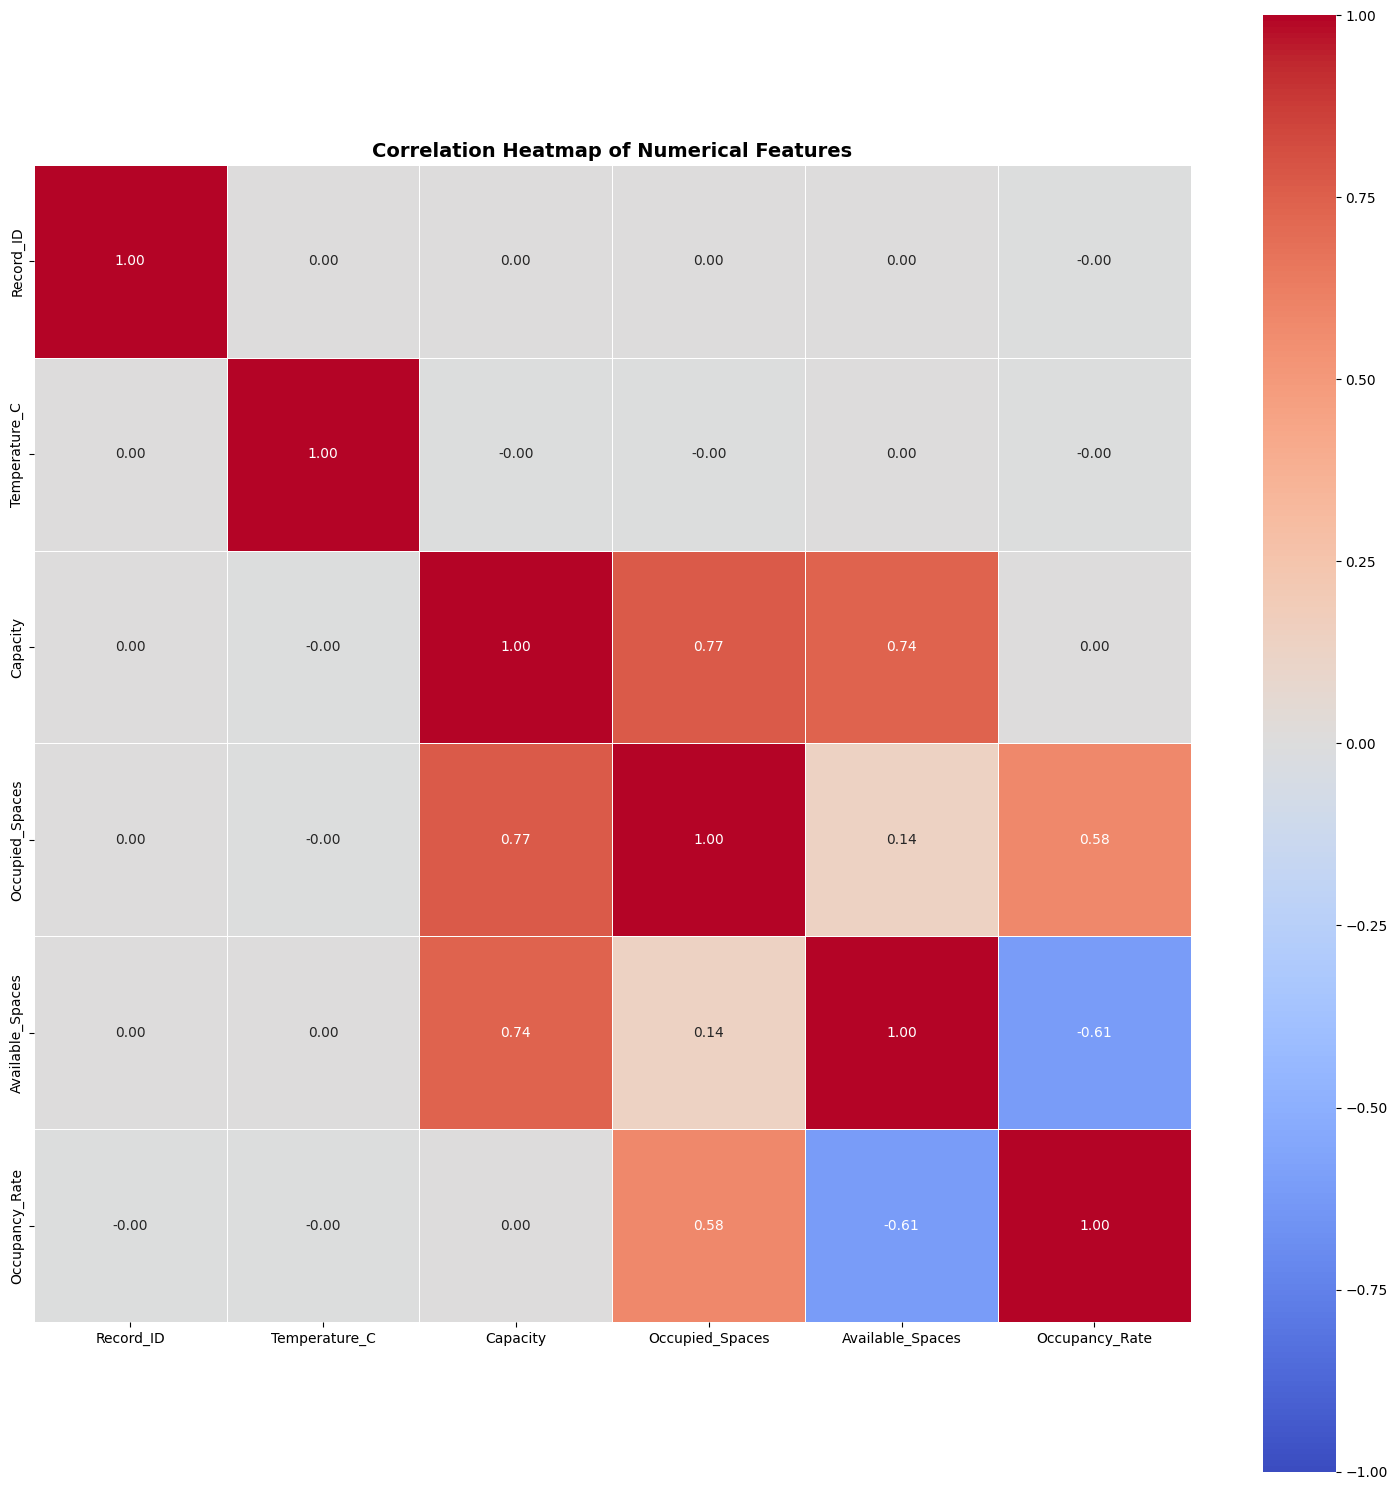

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

In [26]:
import os
output_dir = "/content/"
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: /content/correlation_heatmap.png


In [27]:
target_col = "Parking space Availability"
if target_col in df.columns:
    for col in numerical_cols:
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )
        plt.title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
        plt.xlabel(target_col)
        plt.ylabel(col)
        plt.tight_layout()



        boxplot_filename = f"boxplot_{col}_vs_{target_col}.png"


        boxplot_path = os.path.join(output_dir, boxplot_filename)


        plt.savefig(boxplot_path,    dpi=300,    bbox_inches="tight")


        plt.close()

        print(f"Exported boxplot to: {boxplot_path}")

    else:
        print(f"\nTarget column '{target_col}' not found in dataset. Skipping boxplots.")

        print("\nAll EDA tasks completed successfully!")